# Old

In [9]:
import numpy as np
n = 1000000
res = 0
for _ in range(n):
    d = 10
    u = np.random.normal(0, 1, d+2)  # an array of (d+2) normally distributed random variables
    norm = np.sum(u ** 2) ** (0.5)
    u = u / norm
    res += u[1] ** 2
res / n

0.08327138636261457

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

# Bootstrapping, B=10: 2.3 mins per iteration
# Cross Validation, 

N = 100
objectives = np.loadtxt("../results/raw/dro_wasserstein/result/B_objectives.csv", delimiter=",").reshape((N, 6))
feas_levels = np.loadtxt("../results/raw/dro_wasserstein/result/B_feas_levels.csv", delimiter=",").reshape((N, 6))
mean_feas_level = np.mean(feas_levels, 0)
mean_objectives = np.mean(objectives, 0)

column_names = ['Cross Validation','Bootstrapping','Sectioning','NGS','UNGS','NV']
df = pd.DataFrame(columns=column_names, index=['Proportion Feasible','Mean Objective'])
df.loc['Proportion Feasible'] = pd.Series({name: np.round(val, 3) for name, val in zip(column_names, mean_feas_level)})
df.loc['Mean Objective'] = pd.Series({name: np.round(val, 3) for name, val in zip(column_names, mean_objectives)})
df

,Cross Validation,Bootstrapping,Sectioning,NGS,UNGS,NV
Proportion Feasible,1.0,0.99,1.0,1.0,1.0,1.0
Mean Objective,0.0,-6.458,0.0,0.0,0.0,0.0


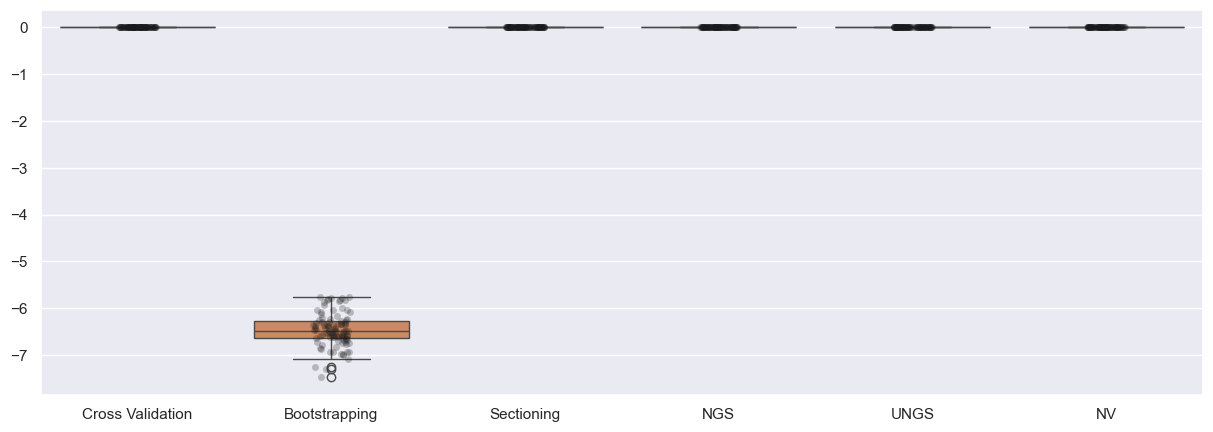

In [4]:
feas_levels_df = pd.DataFrame(feas_levels.reshape((N, 6)), columns=column_names)
objectives_df = pd.DataFrame(objectives.reshape((N, 6)), columns=column_names)

plt.rcParams["figure.figsize"] = (15, 5)
_ = sns.boxplot(objectives_df)
_ = sns.stripplot(objectives_df, color=".1", alpha=0.25)

# Updated

In [222]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
sns.set()

experiment_name = 'dro_moment'
algorithms = ['NV', 'CV', 'BS', 'Sectioning', 'UG', 'NGS', 'UNGS']
names = ['Plain Average', 'Cross Validation', 'Bootstrapping', 'Sectioning', 'Univariate Gaussian',
         'Normalized Gaussian Supremum', 'Unnormalized Gaussian Supremum', ]

df = pd.read_csv(f'../results/final/experiment_results_{experiment_name}.csv')
df_filtered = df[df['Algorithm'].isin(["CV", "BS", "NGS", "UNGS"])]
xlim = [min(df['Objective']) - .1, max(df['Objective']) + .1]
df['n1'] = df['Data Size'] * df['Training Percentage'] / 100
df['n2'] = df['Data Size'] - df['n1']
df.head()

,Objective,Feasibility,Algorithm,Training Percentage,Data Size,Folds,n1,n2
0,-3.469808,1.0,Sectioning,10,100,0,10.0,90.0
1,-3.491478,1.0,NGS,10,100,0,10.0,90.0
2,-3.491478,1.0,UNGS,10,100,0,10.0,90.0
3,-3.491478,1.0,NV,10,100,0,10.0,90.0
4,-3.491478,1.0,UG,10,100,0,10.0,90.0


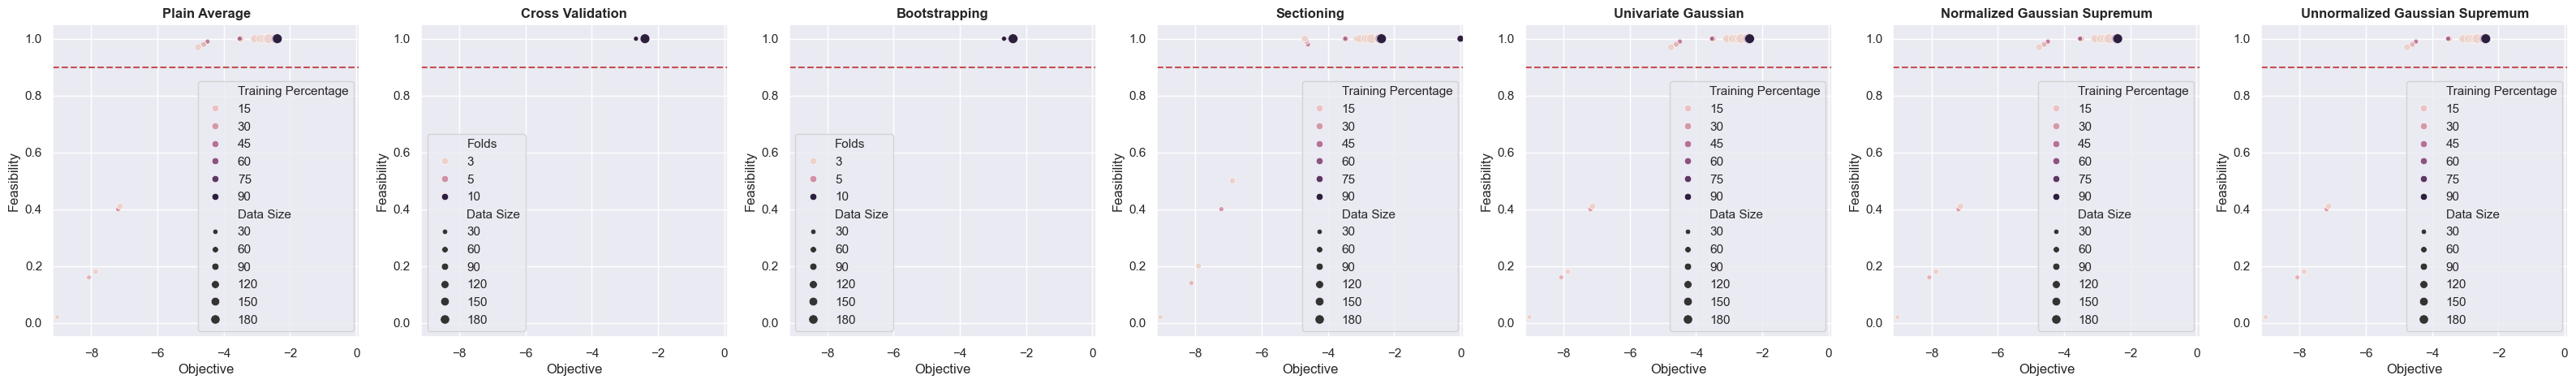

In [223]:
# plt.rcParams["figure.figsize"] = (18, 6)
# _ = sns.scatterplot(data=df, x='Objective', y='Feasibility', hue='Algorithm', style='Algorithm'); plt.ylim([-0.05, 1.05]); plt.xlim(xlim)

# plt.rcParams["figure.figsize"] = (18, 6)
# _ = sns.scatterplot(data=df_filtered, x='Objective', y='Feasibility', hue='Algorithm', style='Algorithm'); plt.ylim([-0.05, 1.05]); plt.xlim(xlim)

plt.rcParams["figure.figsize"] = (40, 5)
for i, alg in enumerate(algorithms):
    plt.subplot(1, len(algorithms), i + 1)
    if alg == 'CV' or alg == 'BS':
        sns.scatterplot(data=df[df['Algorithm'] == alg], x='Objective', y='Feasibility', size='Data Size', hue='Folds')
    else:
        sns.scatterplot(data=df[df['Algorithm'] == alg], x='Objective', y='Feasibility', size='Data Size', hue='Training Percentage')
    # plt.legend(loc='lower right')
    plt.axhline(y=0.9, color='r', linestyle='--')
    plt.title(names[i], fontweight="bold")
    plt.ylim([-0.05, 1.05])
    plt.xlim(xlim)
plt.savefig(f'../results/final/figures/{experiment_name}_all.pdf', bbox_inches='tight')

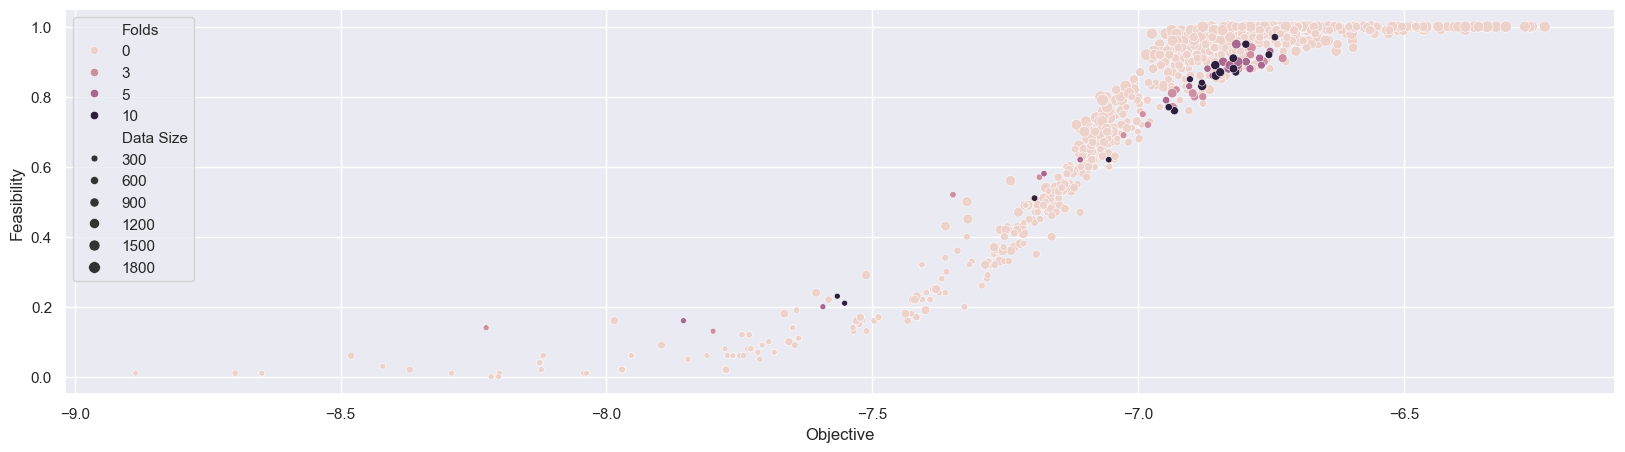

In [195]:
# plt.rcParams["figure.figsize"] = (18, 6)
# _ = sns.scatterplot(data=df[df['Training Percentage'] != 100], x='Objective', y='Feasibility', size='Data Size', hue='Training Percentage')

plt.rcParams["figure.figsize"] = (20, 5)
_ = sns.scatterplot(data=df.sort_values(by=['Folds'], ascending=True), x='Objective', y='Feasibility', hue='Folds', size='Data Size')

## Calibration

In [196]:
df[(df['Algorithm'] == 'UG') & (df['Training Percentage'] == 70)].sort_values(['Data Size', 'Folds', 'Training Percentage'])

,Objective,Feasibility,Algorithm,Training Percentage,Data Size,Folds,n1,n2
34,-7.649563,0.14,UG,70,100,0,70.0,30.0
79,-7.211729,0.49,UG,70,200,0,140.0,60.0
124,-7.039600,0.67,UG,70,300,0,210.0,90.0
169,-6.910969,0.83,UG,70,400,0,280.0,120.0
214,-6.880591,0.81,UG,70,500,0,350.0,150.0
259,-6.807469,0.93,UG,70,600,0,420.0,180.0
304,-6.913858,0.91,UG,70,700,0,490.0,210.0
349,-6.855973,0.90,UG,70,800,0,560.0,240.0
394,-6.873896,0.93,UG,70,900,0,630.0,270.0
439,-6.916969,0.90,UG,70,1000,0,700.0,300.0


In [197]:
pd.DataFrame([df[(df['Algorithm'] == 'UG') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].min(), 
              df[(df['Algorithm'] == 'UG') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].max()])

Data Size,500,600,700,800,900,1000,1100,1200,1300,1400,1500,1600,1700,1800
Training Percentage,60,50,40,50,30,30,20,20,20,20,20,20,20,20
Training Percentage,60,70,70,70,80,90,90,80,80,80,80,80,90,40


In [198]:
pd.DataFrame([df[(df['Algorithm'] == 'UNGS') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].min(), 
              df[(df['Algorithm'] == 'UNGS') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].max()])

Data Size,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500,1600,1700,1800
Training Percentage,60,50,40,30,30,30,30,20,20,20,20,20,20,20,20
Training Percentage,80,80,90,90,90,90,90,90,90,90,90,90,90,90,40


In [199]:
pd.DataFrame([df[(df['Algorithm'] == 'NGS') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].min(), 
              df[(df['Algorithm'] == 'NGS') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].max()])

Data Size,400,500,600,700,800,900,1000,1100,1200,1300,1400,1500,1600,1700,1800
Training Percentage,70,50,40,40,30,30,30,20,20,20,20,20,20,20,20
Training Percentage,70,80,80,80,90,90,90,90,90,90,90,90,90,90,40


In [200]:
pd.DataFrame([df[(df['Algorithm'] == 'Sectioning') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].min(), 
              df[(df['Algorithm'] == 'Sectioning') & (df['Feasibility'] >= 0.9)].groupby('Data Size')['Training Percentage'].max()])

Data Size,500,600,700,800,900,1000,1100,1200,1300,1400,1500,1600,1700,1800
Training Percentage,70,40,40,30,30,30,30,20,20,20,20,20,20,20
Training Percentage,80,80,80,90,90,90,90,90,90,90,90,90,90,40


For small data sizes (100 and 200), no budgeting of $n_1$ and $n_2$ leads to a solution that meets the confidence level. Cross validation, bootstrapping, and sectioning do not lead to a solution that meet the confidence level as well. As the data size increases, solutions that meet the confidence level are found and budgeting can be done more flexibly while still leading to a feasible solution. 

Allocating $70\%$ of the data to $n_1$ and $30\%$ to $n_2$ is contained in all feasible training percentage intervals. 

<Axes: xlabel='n1', ylabel='n2'>

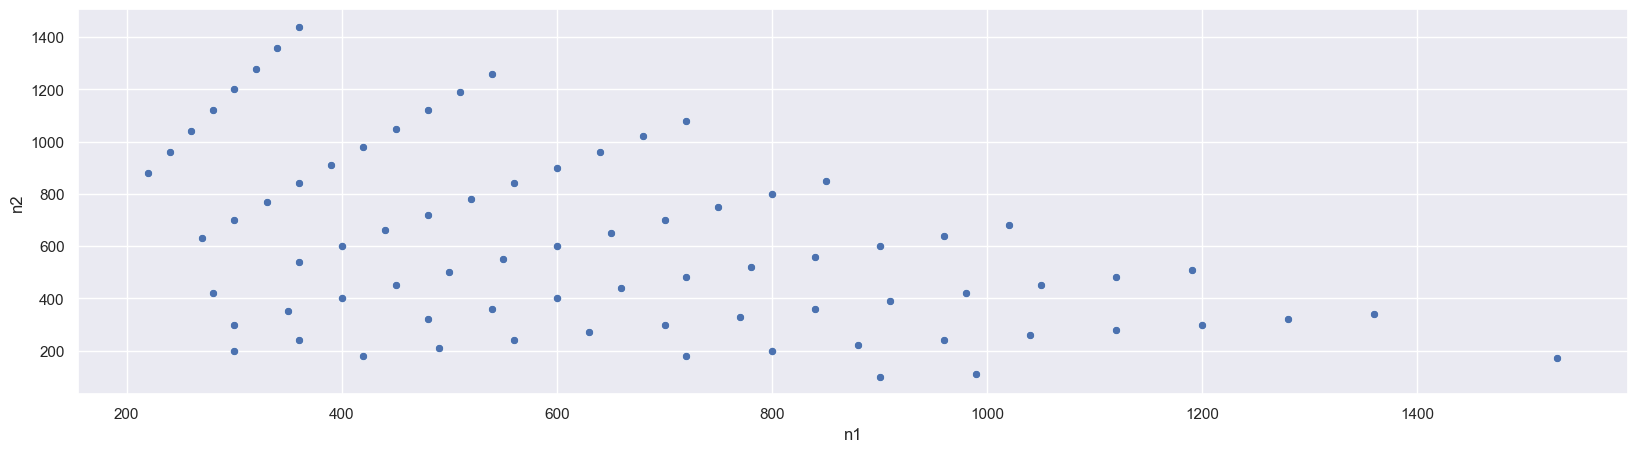

In [201]:
sns.scatterplot(data=df[(df['Algorithm'] == 'UG') & (df['Feasibility'] >= 0.9)][['n1', 'n2']], x='n1', y='n2')

For the problem of SO, $n_1 \geq 210$ and $n_2 \geq 90$ leads to feasible solutions in the numerical experiments.

<Axes: xlabel='Training Percentage', ylabel='Objective'>

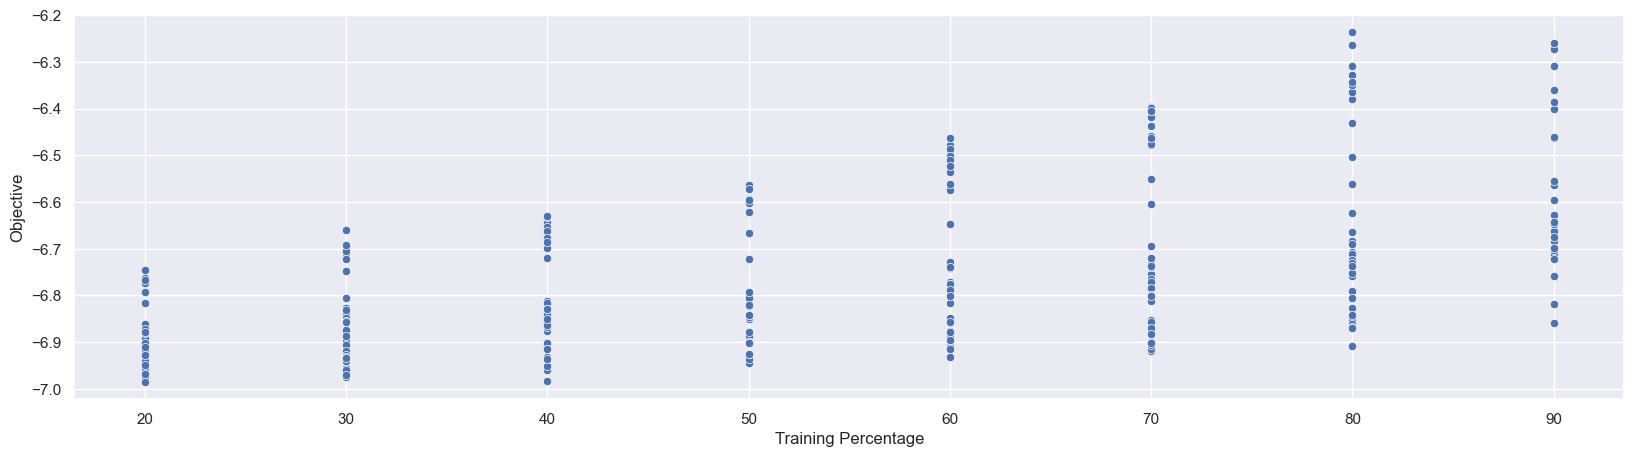

In [202]:
sns.scatterplot(data=df[df['Algorithm'].isin(['UNGS', 'NGS', 'UG']) & (df['Feasibility'] >= 0.9)], x='Training Percentage', y='Objective')

### SO
As the size of $n_1$ compared to $n_2$ increases, the objective value seems to become worse, while an $n_1$ that is too small compared to $n_2$ may lead to the solution not meeting the confidence level. Hence, a sensible choice for the relative budgeting between $n_1$ and $n_2$ seems to be $30\%$ - $70\%$ of the dataset allocated to $n_1$ (and the rest to $n_2$). 
### SAA
As the size of $n_1$ compared to $n_2$ increases, there is not much change in the objective value. A smaller interval for the relative budgeting between $n_1$ and $n_2$ is now required ($50\%$ - $80\%$ of the dataset allocated to $n_1$).

In [203]:
df[(df['Algorithm'] == 'CV') & (df['Feasibility'] >= 0.9)].sort_values(['Data Size', 'Folds'])#.groupby(['Data Size']).sum()

,Objective,Feasibility,Algorithm,Training Percentage,Data Size,Folds,n1,n2
814,-6.791285,0.92,CV,100,500,3,500.0,0.0
820,-6.788493,0.92,CV,100,600,3,600.0,0.0
826,-6.763368,0.90,CV,100,700,3,700.0,0.0
828,-6.797109,0.90,CV,100,700,5,700.0,0.0
832,-6.728313,0.91,CV,100,800,3,800.0,0.0
840,-6.840304,0.90,CV,100,900,5,900.0,0.0
844,-6.787034,0.94,CV,100,1000,3,1000.0,0.0
846,-6.815375,0.95,CV,100,1000,5,1000.0,0.0


In [204]:
df[(df['Algorithm'] == 'CV') & (df['Folds'] == 10)].sort_values(['Data Size', 'Folds'])#.groupby(['Data Size']).sum()

,Objective,Feasibility,Algorithm,Training Percentage,Data Size,Folds,n1,n2
794,-7.565831,0.23,CV,100,100,10,100.0,0.0
800,-7.194832,0.51,CV,100,200,10,200.0,0.0
806,-6.902657,0.85,CV,100,300,10,300.0,0.0
812,-6.942512,0.77,CV,100,400,10,400.0,0.0
818,-6.816388,0.87,CV,100,500,10,500.0,0.0
824,-6.931853,0.76,CV,100,600,10,600.0,0.0
830,-6.820876,0.88,CV,100,700,10,700.0,0.0
836,-6.879727,0.83,CV,100,800,10,800.0,0.0
842,-6.854050,0.86,CV,100,900,10,900.0,0.0


In [205]:
df[(df['Algorithm'] == 'BS') & (df['Feasibility'] >= 0.9)].sort_values(['Data Size', 'Folds'])#.groupby(['Data Size']).sum()

,Objective,Feasibility,Algorithm,Training Percentage,Data Size,Folds,n1,n2
813,-6.742976,0.97,BS,100,400,10,400.0,0.0
817,-6.751937,0.93,BS,100,500,5,500.0,0.0
819,-6.754106,0.92,BS,100,500,10,500.0,0.0
823,-6.771555,0.91,BS,100,600,5,600.0,0.0
825,-6.797441,0.95,BS,100,600,10,600.0,0.0
831,-6.821181,0.91,BS,100,700,10,700.0,0.0
847,-6.811978,0.90,BS,100,1000,5,1000.0,0.0


No specific number of folds leads to a solution that meets the confidence level across all data sizes greater than 300, in contrast to setting $n_1$ to $70\%$ of the data size. Not sure why 10 folds works for all sizes greater than 300 excluding 600... 

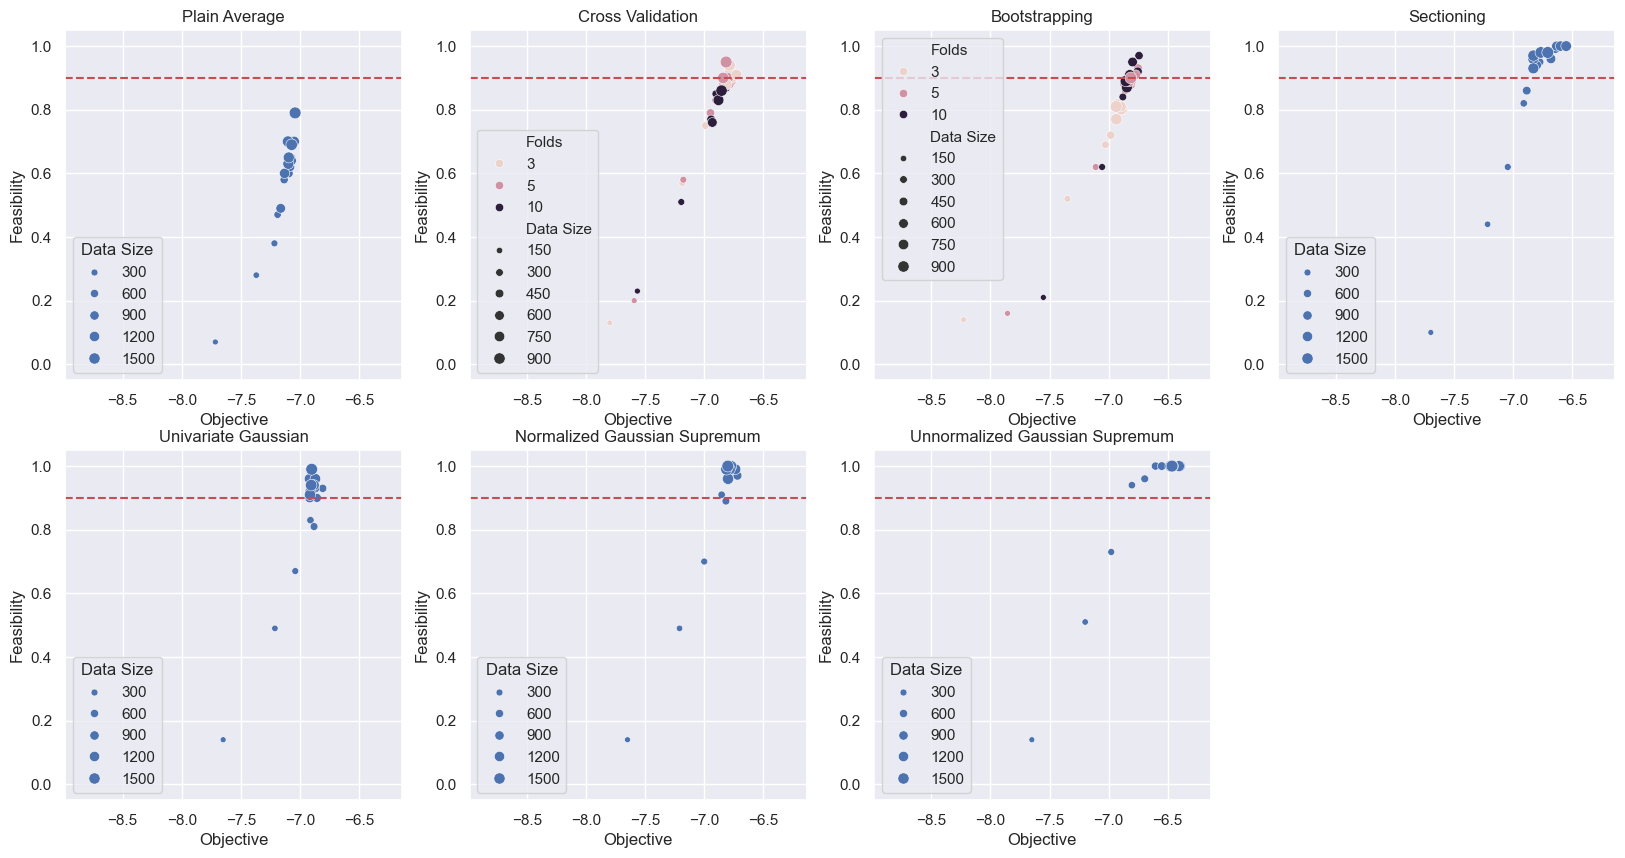

In [206]:
# plt.rcParams["figure.figsize"] = (25, 20)
# algorithms = ['CV', 'BS', 'Sectioning', 'NV', 'NGS', 'UNGS']
# names = ['Cross Validation', 'Bootstrapping', 'Sectioning', 'NV', 'NGS', 'UNGS']
# for i, alg in enumerate(algorithms):
#     plt.subplot(3, 2, i + 1)
#     if alg == 'CV' or alg == 'BS':
#         sns.scatterplot(data=df[(df['Algorithm'] == alg) & (df['Data Size'] >= 300)], x='Objective', y='Feasibility', size='Data Size', hue='Folds')
#     else:
#         sns.scatterplot(data=df[(df['Algorithm'] == alg) & (df['n1'] >= 210) & (df['n2'] >= 90) & (df['Training Percentage'] <= 70) & (df['Training Percentage'] >= 30)], 
#                         x='Objective', y='Feasibility', size='Data Size', hue='Training Percentage')
#     plt.axhline(y=0.9, color='r', linestyle='--')
#     plt.title(names[i])
#     plt.ylim([-0.05, 1.05])
#     plt.xlim(xlim)

plt.rcParams["figure.figsize"] = (20, 10)
for i, alg in enumerate(algorithms):
    plt.subplot(2, 4, i + 1)
    if alg == 'CV' or alg == 'BS':
        sns.scatterplot(data=df[(df['Algorithm'] == alg)], x='Objective', y='Feasibility', size='Data Size', hue='Folds')
    else:
        sns.scatterplot(data=df[(df['Algorithm'] == alg) & (df['Training Percentage'] == 70)], 
                        x='Objective', y='Feasibility', size='Data Size')
    plt.axhline(y=0.9, color='r', linestyle='--')
    plt.title(names[i])
    plt.ylim([-0.05, 1.05])
    plt.xlim(xlim)

In [207]:
min_data_size = 200 if experiment_name == 'ro_ellipsoid' else \
    10 if experiment_name == 'dro_moment' or experiment_name == "dro_wasserstein" else 300

plt.rcParams["figure.figsize"] = (16, 3.5)
ylim = [-.75, .75] if experiment_name == 'ro_ellipsoid' else [-0.2, 0.2]
xlim = [min_data_size - max(df['Data Size']) * 0.05, max(df['Data Size']) + max(df['Data Size']) * 0.05]

# minimum/best
folds = 3
bootstraps = 5
# cv_df = df[(df['Algorithm'] == 'CV') & (df['Data Size'] >= min_data_size) & (df['Feasibility'] >= 0.9) & (df['Folds'] == folds)].sort_values(['Data Size', 'Objective'], ascending=True).drop_duplicates('Data Size')
# bs_df = df[(df['Algorithm'] == 'BS') & (df['Data Size'] >= min_data_size) & (df['Feasibility'] >= 0.9) & (df['Folds'] == bootstraps)].sort_values(['Data Size', 'Objective'], ascending=True).drop_duplicates('Data Size')
cv_df = df[(df['Algorithm'] == 'CV') & (df['Data Size'] >= min_data_size) & (df['Folds'] == folds)].sort_values(['Data Size', 'Objective'], ascending=True).drop_duplicates('Data Size')
bs_df = df[(df['Algorithm'] == 'BS') & (df['Data Size'] >= min_data_size) & (df['Folds'] == bootstraps)].sort_values(['Data Size', 'Objective'], ascending=True).drop_duplicates('Data Size')

# cv_obj = cv_df['Objective'].to_numpy()
# bs_obj = bs_df['Objective'].to_numpy()

# mean
# cv_obj_10 = df[(df['Algorithm'] == 'CV') & (df['Data Size'] >= min_data_size) & (df['Feasibility'] >= 0.9) & (df['Folds'] == folds)].groupby('Data Size')['Objective'].mean().to_numpy()
# bs_obj_10 = df[(df['Algorithm'] == 'BS') & (df['Data Size'] >= min_data_size) & (df['Feasibility'] >= 0.9) & (df['Folds'] == bootstraps)].groupby('Data Size')['Objective'].mean().to_numpy()
cv_obj_10 = df[(df['Algorithm'] == 'CV') & (df['Data Size'] >= min_data_size) & (df['Folds'] == folds)].groupby('Data Size')['Objective'].mean().to_numpy()
bs_obj_10 = df[(df['Algorithm'] == 'BS') & (df['Data Size'] >= min_data_size) & (df['Folds'] == bootstraps)].groupby('Data Size')['Objective'].mean().to_numpy()

# GS and Sec
training_percentage = 70
ug_70 = df[(df['Algorithm'] == 'UG') & (df['Data Size'] >= min_data_size) & (df['Training Percentage'] == training_percentage)].sort_values('Data Size')
# ug_70 = df[(df['Algorithm'] == 'UG') & (df['Data Size'].between(60, 200)) & (df['Training Percentage'] == training_percentage)].sort_values('Data Size')
ungs_70 = df[(df['Algorithm'] == 'UNGS') & (df['Data Size'] >= min_data_size) & (df['Training Percentage'] == training_percentage)].sort_values('Data Size')
ngs_70 = df[(df['Algorithm'] == 'NGS') & (df['Data Size'] >= min_data_size) & (df['Training Percentage'] == training_percentage)].sort_values('Data Size')
sec_df = df[(df['Algorithm'] == 'Sectioning') & (df['Feasibility'] >= 0.9) & (df['Training Percentage'] == training_percentage)].sort_values('Data Size')

sec_obj = sec_df['Objective'].to_numpy() 
ngs_obj = ngs_70['Objective'].to_numpy()
ungs_obj = ungs_70['Objective'].to_numpy()
ug_obj = ug_70['Objective'].to_numpy()

In [208]:
# plt.subplot(1, 3, 1)
# if experiment_name == 'so':
#     plt.plot(ug_70['Data Size'], bs_obj_10 - ug_obj, label='Bootstrapping', marker='x')
#     plt.plot([300, 400, 500, 700, 800, 900, 1000], 
#             cv_obj_10 - np.delete(ug_obj, 3), label='Cross Validation', marker='x')
#     plt.plot(ug_70['Data Size'][1:], sec_obj - ug_obj[1:], label='Sectioning', marker='x')
# elif experiment_name == 'saa':
#     plt.plot(ug_70['Data Size'][1:], bs_obj_10[1:] - ug_obj[1:], label='Bootstrapping', marker='x')
#     plt.plot(ug_70['Data Size'][1:], cv_obj_10[1:] - ug_obj[1:], label='Cross Validation', marker='x')
#     plt.plot(ug_70['Data Size'][1:], sec_obj - ug_obj[1:], label='Sectioning', marker='x')
# else:
#     plt.plot(ug_70['Data Size'], bs_obj_10 - ug_obj, label='Bootstrapping', marker='x')
#     plt.plot(ug_70['Data Size'], cv_obj_10 - ug_obj, label='Cross Validation', marker='x')
#     plt.plot(ug_70['Data Size'], sec_obj - ug_obj, label='Sectioning', marker='x')
# plt.legend(); plt.xlabel('Data Size'); plt.ylabel('$\Delta$ Objective')
# plt.title('Univariate Gaussian Baseline', fontweight="bold"); plt.ylim(ylim); plt.xlim(xlim)
# _ = plt.axhline(y=0., color='k', linestyle='--')

# plt.subplot(1, 3, 2)
# plt.plot(ungs_70['Data Size'], bs_obj_10 - ungs_obj, label='Bootstrapping', marker='x')
# if experiment_name == 'so':
#     plt.plot([300, 400, 500, 700, 800, 900, 1000], 
#             cv_obj_10 - np.delete(ungs_obj, 3), label='Cross Validation', marker='x')
#     plt.plot(ungs_70['Data Size'][1:], sec_obj - ungs_obj[1:], label='Sectioning', marker='x')
# elif experiment_name == 'saa':
#     plt.plot(ungs_70['Data Size'], cv_obj_10 - ungs_obj, label='Cross Validation', marker='x')
#     plt.plot(ungs_70['Data Size'][1:], sec_obj - ungs_obj[1:], label='Sectioning', marker='x')
# else:
#     plt.plot(ungs_70['Data Size'], cv_obj_10 - ungs_obj, label='Cross Validation', marker='x')
#     plt.plot(ungs_70['Data Size'], sec_obj - ungs_obj, label='Sectioning', marker='x')
# # plt.plot(ungs_70['Data Size'], ungs_obj - ngs_obj, label='NGS')
# plt.legend(); plt.xlabel('Data Size'); plt.ylabel('$\Delta$ Objective')
# plt.title('Unnormalized Gaussian Supremum Baseline', fontweight="bold"); plt.ylim(ylim); plt.xlim(xlim)
# _ = plt.axhline(y=0., color='k', linestyle='--')

# plt.subplot(1, 3, 3)
# plt.plot(ngs_70['Data Size'], bs_obj_10 - ngs_obj, label='Bootstrapping', marker='x')
# if experiment_name == 'so':
#     plt.plot([300, 400, 500, 700, 800, 900, 1000], 
#             cv_obj_10 - np.delete(ngs_obj, 3), label='Cross Validation', marker='x')
#     plt.plot(ngs_70['Data Size'][1:], sec_obj - ngs_obj[1:], label='Sectioning', marker='x')
# elif experiment_name == 'saa':
#     plt.plot(ngs_70['Data Size'], cv_obj_10 - ngs_obj, label='Cross Validation', marker='x')
#     plt.plot(ngs_70['Data Size'][1:], sec_obj - ngs_obj[1:], label='Sectioning', marker='x')
# else:
#     plt.plot(ngs_70['Data Size'], cv_obj_10 - ngs_obj, label='Cross Validation', marker='x')
#     plt.plot(ngs_70['Data Size'], sec_obj - ngs_obj, label='Sectioning', marker='x')
# plt.legend(); plt.xlabel('Data Size'); plt.ylabel('$\Delta$ Objective')
# plt.title('Normalized Gaussian Supremum Baseline', fontweight="bold"); plt.ylim(ylim); plt.xlim(xlim)
# _ = plt.axhline(y=0., color='k', linestyle='--')

# # plt.savefig(f'../results/final/figures/{experiment_name}_delta_objective.pdf', bbox_inches='tight')

Change in objective compared to baseline (positive means performed worse than baseline) for data sizes greater than 300 (no algorithm met the confidence level for smaller data sets). 

Mean objective shows that both UNGS and NGS outperforms BS for all data sizes, Sectioning for most data sizes (note that sectioning did not meet the confidence level at $n=300$ while UNGS and NGS did), and performed similarly to CV. 

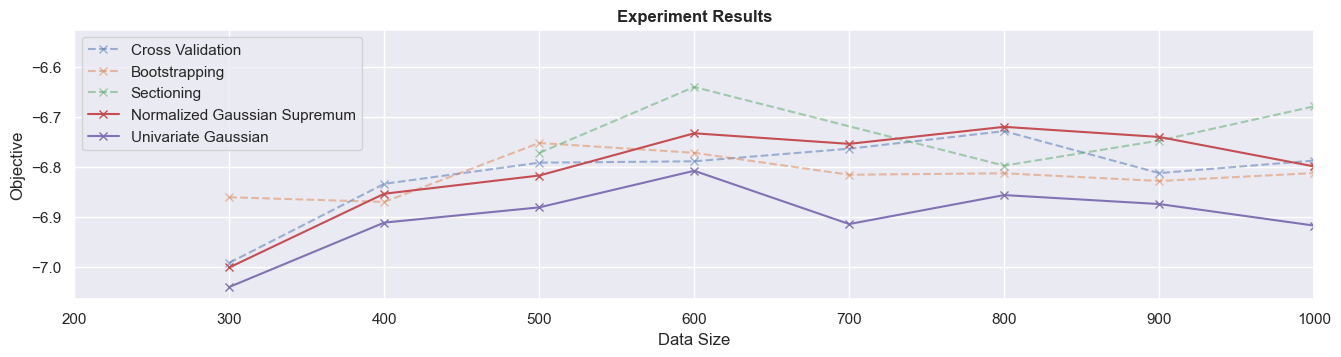

In [209]:
if experiment_name == 'ro_ellipsoid':
    plt.hlines(y=-6.58765, xmin=200, xmax=2000, color='black', linestyle='--', label="SCA baseline")
plt.plot(cv_df['Data Size'], cv_obj_10, '--', label='Cross Validation', marker='x', alpha=0.5)
plt.plot(bs_df['Data Size'], bs_obj_10, '--', label='Bootstrapping', marker='x', alpha=0.5)
plt.plot(sec_df['Data Size'], sec_obj, '--', label='Sectioning', marker='x', alpha=0.5)
plt.plot(ngs_70['Data Size'], ngs_obj, label='Normalized Gaussian Supremum', marker='x')
# plt.plot(ungs_70['Data Size'], ungs_obj, label='Unnormalized Gaussian Supremum', marker='x')
plt.plot(ug_70['Data Size'], ug_obj, label='Univariate Gaussian', marker='x')
plt.xlabel('Data Size'); plt.ylabel('Objective')
plt.title(f'Experiment Results', fontweight="bold")
plt.legend()
plt.xlim([200, 1000])
plt.savefig("../results/final/figures/"+experiment_name+"_comparison.pdf", bbox_inches='tight')